In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

# ============================================================
# 1. 生成复合周期性数据（支持随机相位）
# ============================================================
def generate_periodic_data(n_samples=2000, dt=0.01, random_phase=True):
    t = np.arange(n_samples) * dt

    # 相位控制：随机化或固定
    if random_phase:
        phase1 = np.random.uniform(0, 2 * np.pi)
        phase2 = np.random.uniform(0, 2 * np.pi)
        phase3 = np.random.uniform(0, 2 * np.pi)
    else:
        phase1, phase2, phase3 = 0.3, 1.0, 2.0

    # 频率保持固定：主周期5s，谐波比例1:3:6，振幅比例2:1:0.5
    y = (
        2.0 * np.sin(2 * np.pi * 0.2 * t + phase1)   # 主周期分量
        + 1.0 * np.sin(2 * np.pi * 0.6 * t + phase2) # 二次谐波
        + 0.5 * np.sin(2 * np.pi * 1.2 * t + phase3) # 高频分量
    )
    return t, y, (phase1, phase2, phase3)

# 生成带随机相位的数据
t_total, y_total, phases = generate_periodic_data(n_samples=2000, dt=0.01, random_phase=True)
y_total = y_total.reshape(-1, 1)

print(f"当前数据相位（主波/二次谐波/高频分量）：{phases[0]:.3f}, {phases[1]:.3f}, {phases[2]:.3f} rad")

# 划分数据集：前80%阅读更新状态，后20%自回归预测
split_idx = int(len(y_total) * 0.8)
y_train = y_total[:split_idx]
y_test = y_total[split_idx:]
t_train = t_total[:split_idx]
t_test = t_total[split_idx:]

# 转为Tensor
y_train_t = torch.FloatTensor(y_train)
y_test_t = torch.FloatTensor(y_test)


当前数据相位（主波/二次谐波/高频分量）：4.622, 1.332, 0.899 rad


In [2]:
# ============================================================
# 2. 基础离散状态空间模型 (SSM)（扩参+优化初始化，结构不变）
# ============================================================
class SimpleSSM(nn.Module):
    """
    标准线性状态空间模型：
    x_{k+1} = A @ x_k + B @ u_k
    y_{k+1} = C @ x_{k+1} + D @ u_k
    仅调整状态维度与初始化方式，核心结构未改动
    """
    def __init__(self, state_dim=128, input_dim=1, output_dim=1):
        super().__init__()
        self.state_dim = state_dim
        self.input_dim = input_dim
        self.output_dim = output_dim

        # A矩阵：对角占优初始化 + 小噪声，保证初始稳定性与长记忆性
        self.A = nn.Parameter(torch.eye(state_dim) * 0.98 + torch.randn(state_dim, state_dim) * 0.01)
        self.B = nn.Parameter(torch.randn(state_dim, input_dim) * 0.1)
        self.C = nn.Parameter(torch.randn(output_dim, state_dim) * 0.1)
        self.D = nn.Parameter(torch.zeros(output_dim, input_dim))

        # 初始化后校准谱半径，确保离散系统稳定
        with torch.no_grad():
            spec_radius = torch.linalg.matrix_norm(self.A, ord=2)
            self.A.data = self.A / (spec_radius + 1e-6) * 0.98

    def step(self, x_prev, u):
        """单步状态更新与预测"""
        x_next = self.A @ x_prev + self.B @ u
        y = self.C @ x_next + self.D @ u
        return x_next, y

    def forward_sequence(self, u_seq, x0=None):
        """批量处理序列，返回所有单步预测与最终状态"""
        T = u_seq.shape[0]
        if x0 is None:
            x = torch.zeros(self.state_dim, 1, device=u_seq.device)
        else:
            x = x0

        outputs = []
        for t in range(T):
            u_t = u_seq[t].reshape(-1, 1)
            x, y_t = self.step(x, u_t)
            outputs.append(y_t.squeeze(-1))

        outputs = torch.stack(outputs, dim=0)
        return outputs, x

    def autoregressive_generate(self, x0, u0, steps):
        """纯自回归生成：用自身输出作为下一步输入"""
        x = x0
        u = u0
        generated = []

        for _ in range(steps):
            x, y = self.step(x, u)
            generated.append(y.squeeze(-1))
            u = y

        generated = torch.stack(generated, dim=0)
        return generated


In [3]:
# ============================================================
# 3. 训练模型（窗口大小=1，仅用前一个点预测下一个点）
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleSSM(state_dim=128, input_dim=1, output_dim=1).to(device)
optimizer = optim.Adam(model.parameters(), lr=3e-4)
criterion = nn.MSELoss()

# 训练对：输入y[0:-1]，目标y[1:]（单步预测）
u_train = y_train_t[:-1].to(device)
y_target = y_train_t[1:].to(device)

epochs = 2000
loss_history = []

for epoch in range(epochs):
    optimizer.zero_grad()
    pred, _ = model.forward_sequence(u_train)
    loss = criterion(pred, y_target)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    loss_history.append(loss.item())

    if (epoch + 1) % 400 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {loss.item():.6f}")


Epoch 400/2000, Train Loss: 0.001353
Epoch 800/2000, Train Loss: 0.000428
Epoch 1200/2000, Train Loss: 0.000310
Epoch 1600/2000, Train Loss: 0.000260
Epoch 2000/2000, Train Loss: 0.000217


当前测试相位（主波/二次谐波/高频分量）：0.125, 3.360, 3.189 rad
自回归测试集 MSE: 0.657386


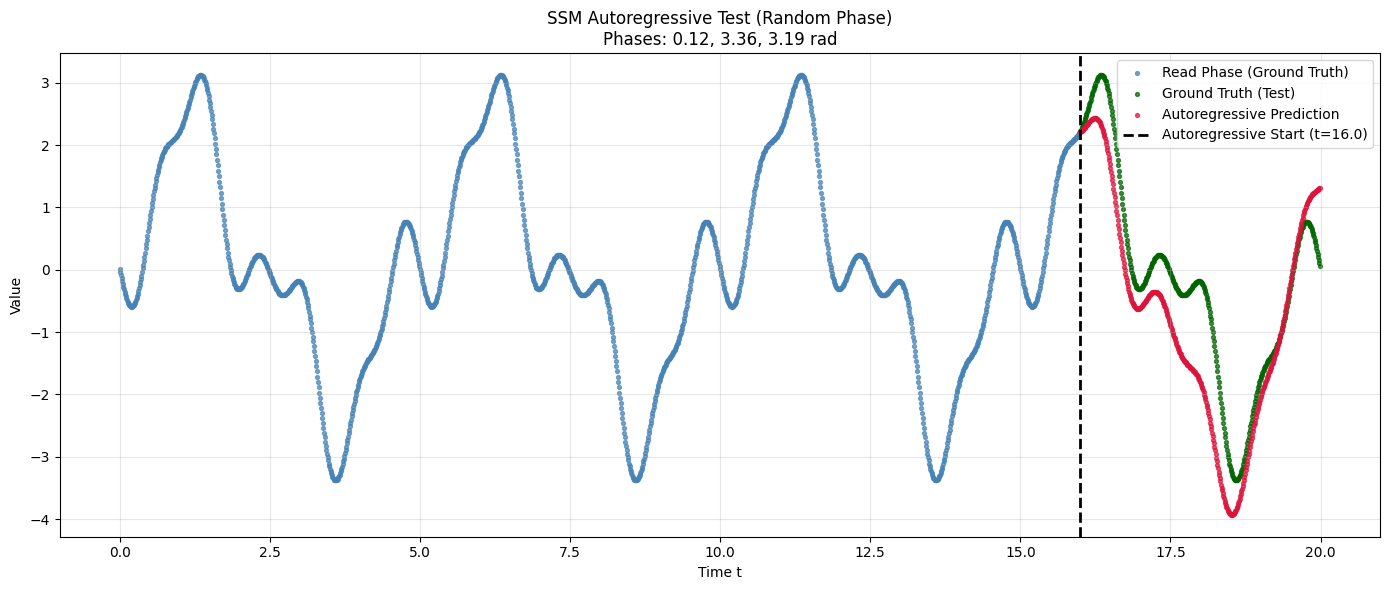

In [6]:
# ============================================================
# 4. 推理：阅读80%更新状态，自回归预测剩余20%
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import torch

# 1. 生成新的随机相位周期性数据（每次运行相位都不同）
def generate_periodic_data(n_samples=2000, dt=0.01):
    t = np.arange(n_samples) * dt
    phase1 = np.random.uniform(0, 2 * np.pi)
    phase2 = np.random.uniform(0, 2 * np.pi)
    phase3 = np.random.uniform(0, 2 * np.pi)

    y = (
        2.0 * np.sin(2 * np.pi * 0.2 * t + phase1)   # 主周期分量
        + 1.0 * np.sin(2 * np.pi * 0.6 * t + phase2) # 二次谐波
        + 0.5 * np.sin(2 * np.pi * 1.2 * t + phase3) # 高频分量
    )
    return t, y, (phase1, phase2, phase3)

t_total, y_total, phases = generate_periodic_data(n_samples=2000, dt=0.01)
y_total = y_total.reshape(-1, 1)
print(f"当前测试相位（主波/二次谐波/高频分量）：{phases[0]:.3f}, {phases[1]:.3f}, {phases[2]:.3f} rad")

# 2. 划分阅读段（更新状态）与预测段（自回归）
split_idx = int(len(y_total) * 0.8)
y_read = y_total[:split_idx]
y_true = y_total[split_idx:]
t_read = t_total[:split_idx]
t_pred = t_total[split_idx:]

y_read_t = torch.FloatTensor(y_read).to(device)

# 3. 状态预热 + 纯自回归预测
model.eval()
with torch.no_grad():
    # 前80%数据喂入模型，更新得到最终状态
    _, x_final = model.forward_sequence(y_read_t[:-1])
    # 以阅读段最后一个真实值为起点，自回归生成后续全部数据
    u_init = y_read_t[-1].reshape(-1, 1)
    pred_autoregressive = model.autoregressive_generate(x_final, u_init, steps=len(y_true))
    pred_autoregressive = pred_autoregressive.cpu().numpy()

# 4. 量化误差
test_mse = np.mean((pred_autoregressive - y_true) ** 2)
print(f"自回归测试集 MSE: {test_mse:.6f}")

# 5. 可视化（散点图+竖线区分）
plt.figure(figsize=(14, 6))
plt.scatter(t_read, y_read, s=8, c='steelblue', label='Read Phase (Ground Truth)', alpha=0.7)
plt.scatter(t_pred, y_true, s=8, c='darkgreen', label='Ground Truth (Test)', alpha=0.7)
plt.scatter(t_pred, pred_autoregressive, s=8, c='crimson', label='Autoregressive Prediction', alpha=0.7)
plt.axvline(x=t_total[split_idx], color='black', linestyle='--', linewidth=2,
            label=f'Autoregressive Start (t={t_total[split_idx]:.1f})')

plt.xlabel('Time t')
plt.ylabel('Value')
plt.title(f'SSM Autoregressive Test (Random Phase)\nPhases: {phases[0]:.2f}, {phases[1]:.2f}, {phases[2]:.2f} rad')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
